# Data Exploration and Analysis

This step isn't necessary, I just want to get an idea of what the data looks like as a fan of the sport. For all modeling purposes, please skip to the third notebook titled modeling.

Here, we're just going to bring in our dataframe and take a look at the data to decided what we may want to graph

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None) 

In [2]:
df = pd.read_csv('../data/df.csv')

df.head()

,RedFighter,BlueFighter,RedOdds,BlueOdds,RedWinner,RedReturn,BlueReturn,OddsDiff,AgeDiff,ReachDiff,WinsDiff,LossesDiff,WinStreakDiff,LoseStreakDiff,RankDiff,Date,TitleBout,WeightClass,Gender,NumberOfRounds,Finish,FinishRound,BlueCurrentLoseStreak,BlueCurrentWinStreak,BlueLongestWinStreak,BlueLosses,BlueTotalRoundsFought,BlueTotalTitleBouts,BlueWinsByKO,BlueWinsBySubmission,BlueWins,BlueStance,BlueHeightCms,BlueReachCms,BlueAge,BMatchWCRank,RedCurrentLoseStreak,RedCurrentWinStreak,RedLongestWinStreak,RedLosses,RedTotalRoundsFought,RedTotalTitleBouts,RedWinsByKO,RedWinsBySubmission,RedWins,RedStance,RedHeightCms,RedReachCms,RedAge,RMatchWCRank
0,Colby Covington,Joaquin Buckley,205,-250,False,0.0000,1.4000,455,6,-10.16,2,0,-5,1,-3,2024-12-14,False,Welterweight,MALE,5,KO/TKO,3,0,5,5,4,34,0,7,0,10,Southpaw,177.80,193.04,30,9,1,0,7,4,58,4,3,2,12,Orthodox,180.34,182.88,36,6
1,Cub Swanson,Billy Quarantillo,124,-148,True,2.2400,0.0000,272,5,0.00,12,9,0,0,0,2024-12-14,False,Featherweight,MALE,3,KO/TKO,3,1,0,4,4,28,0,4,1,7,Orthodox,177.80,177.80,36,20,1,0,6,13,82,0,6,2,19,Orthodox,172.72,177.80,41,20
2,Manel Kape,Bruno Silva,-395,310,True,1.2532,0.0000,-705,-3,7.62,0,1,-4,1,-3,2024-12-14,False,Flyweight,MALE,3,KO/TKO,3,0,4,4,2,16,0,3,1,4,Orthodox,162.56,165.10,34,12,1,0,4,3,17,0,2,0,4,Southpaw,165.10,172.72,31,9
3,Vitor Petrino,Dustin Jacoby,-340,270,False,0.0000,3.7000,-610,-9,2.54,-3,-5,0,-1,0,2024-12-14,False,Light Heavyweight,MALE,3,KO/TKO,3,2,0,4,6,35,0,4,0,8,Orthodox,190.50,193.04,36,20,1,0,5,1,14,0,2,1,5,Orthodox,187.96,195.58,27,20
4,Adrian Yanez,Daniel Marcos,185,-225,False,0.0000,1.4444,410,0,2.54,3,2,-3,0,0,2024-12-14,False,Bantamweight,MALE,3,S-DEC,3,0,4,4,0,13,0,1,0,4,Orthodox,170.18,175.26,31,20,0,1,6,2,15,0,6,0,7,Orthodox,170.18,177.80,31,20


## 1. Fight Odds

Let's take a look at the average return on each column to see what we're working with.

In [3]:
avgRed = round(df['RedReturn'].mean(), 4)
avgBlue = round(df['BlueReturn'].mean(), 4)

print("All red bets will change your money by a factor of " + str(avgRed) + " while all blue bets would see a factor of " + str(avgBlue))

All red bets will change your money by a factor of 1.0041 while all blue bets would see a factor of 0.8965


All red bets would have seen an increase of .41% of money bet, while all blue bets would've decreased your money by over 10%. That difference is how the house always wins, and that's what we're trying to beat. Let's take a look at the odds for red and blue, discounting extreme outliars of odds exceeding -1000 or +700

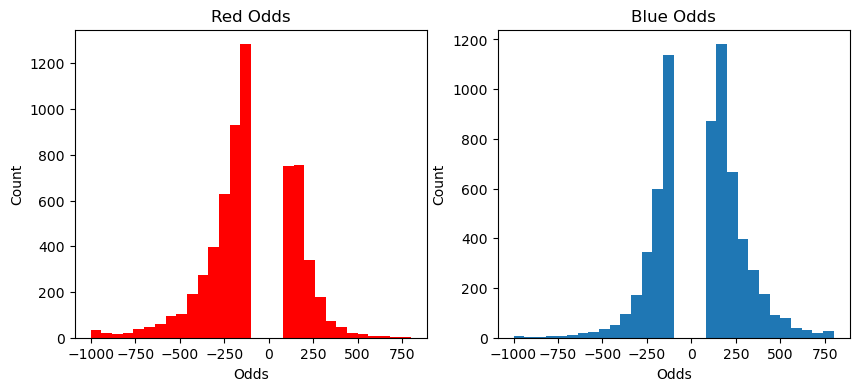

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist(df.RedOdds, bins=30, range = (-1000, 800), color='Red')
ax1.set_xlabel('Odds')
ax1.set_ylabel('Count')
ax1.set_title('Red Odds')

ax2.hist(df.BlueOdds, bins=30, range = (-1000, 800))
ax2.set_xlabel('Odds')
ax2.set_ylabel('Count')
ax2.set_title('Blue Odds')

plt.show()

The data here looks very similar, each with nothing below 100 on either side. We do see some more slight underdogs out of the blue corner and more slight favorites from the red.

Let's take a look at some big underdog winners from each corner.

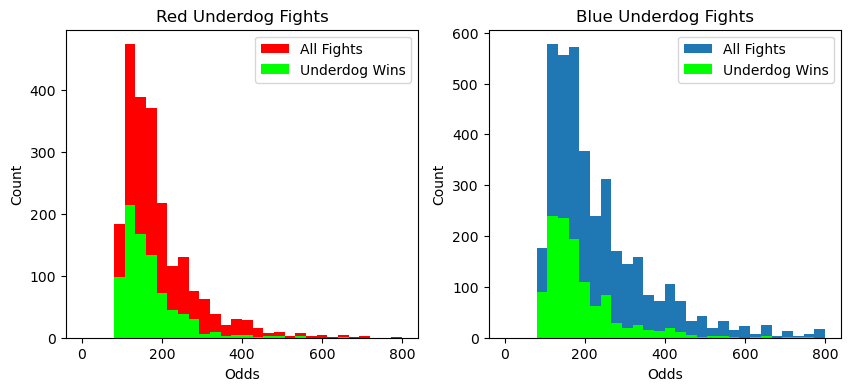

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist(df.RedOdds, bins=30, range = (0, 800), label = 'All Fights', color='Red')
ax1.hist(df.loc[df['RedWinner'] == True, 'RedOdds'], bins=30, range = (0, 800), label = 'Underdog Wins', color='lime')
ax1.set_xlabel('Odds')
ax1.set_ylabel('Count')
ax1.set_title('Red Underdog Fights')
ax1.legend()

ax2.hist(df.BlueOdds, bins=30, range = (0, 800), label = 'All Fights')
ax2.hist(df.loc[df['RedWinner'] == False, 'BlueOdds'], bins=30, range = (0, 800), label = 'Underdog Wins', color='lime')
ax2.set_xlabel('Odds')
ax2.set_ylabel('Count')
ax2.set_title('Blue Underdog Fights')
ax2.legend()

plt.show()

We Can see here that as the odds get worse, the underdog is less likely to win. There are a couple of spikes around the +300 and +400 mark of the blue corner, as well as around 50% chance the underdog wins in the red corner for the first couple columns. Those are spots where I want my model to target and make its money. Let's take a look at the same kind of data, except this time from what the computer will see: odds difference vs result.

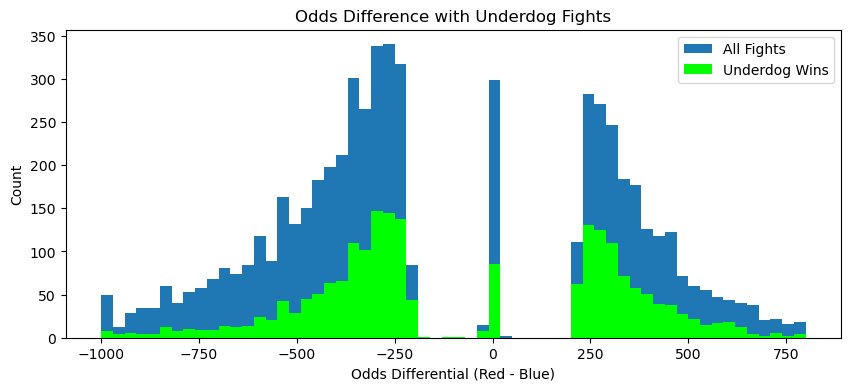

Red upset rate: 38.1711
Blue upset rate: 30.253
Total upset rate: 32.93122356258812


In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(df['OddsDiff'], bins=60, range=(-1000, 800), label='All Fights')

underdogWins = df[((df['RedWinner'] == True) & (df['OddsDiff'] > 0)) |
                   ((df['RedWinner'] == False) & (df['OddsDiff'] < 0))]

ax.hist(underdogWins['OddsDiff'], bins=60, range=(-1000, 800), color='lime', label='Underdog Wins')

ax.set_xlabel('Odds Differential (Red - Blue)')
ax.set_ylabel('Count')
ax.set_title('Odds Difference with Underdog Fights')
ax.legend()

plt.show()

totalFights = len(df)
upsetWins = len(underdogWins)

upsetRate = (upsetWins / totalFights) * 100
redUnderdogFights  = df[df['RedOdds'] > 0]
blueUnderdogFights = df[df['BlueOdds'] > 0]
redUpsets  = len(redUnderdogFights[redUnderdogFights['RedWinner'] == True])
blueUpsets = len(blueUnderdogFights[blueUnderdogFights['RedWinner'] == False])
redUpsetRate = round((redUpsets / len(redUnderdogFights)) * 100, 4)
blueUpsetRate = round((blueUpsets / len(blueUnderdogFights)) * 100, 4)

print('Red upset rate: ' + str(redUpsetRate))
print('Blue upset rate: ' + str(blueUpsetRate))
print('Total upset rate: ' + str(upsetRate))

From this chart, things look really close on the right side. Since the odds differential is Red-Blue, The right side of the chart is showing us how often Red upsets Blue. We can also see from the data that red corner underdogs win over 38% of the time, but the red corner is less often the underdog. Our model's ability to find out why will be crucial to our success.

## 2. Age

Combat sports are very hard on the body. Most fighters are in their prime until they're not, and once a losing streak starts the ball keeps on rolling. While each fighter is different and some age sooner than others due to quantity/severity of previous fights or the way they train, 